# K-Means Clustering: Tech Support Ticket Segmentation

## Problem Statement
Group technical-support interactions into clusters to identify common patterns in support demand.

## Dataset
**Technical Support Data** -- support-ticket-level features.

## Approach
Standardization followed by K-Means clustering, with cluster count chosen via inspection (e.g. elbow-style reasoning) and cluster profiles summarized.

## Conclusion
Surfaces distinct support-ticket clusters, useful for staffing/triage decisions.


In [4]:
#Technical Support Data Analysis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from scipy.stats import zscore

In [6]:
data = pd.read_csv('technical_support_data.csv')

In [7]:
data.shape

(23, 8)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PROBLEM_TYPE           23 non-null     object 
 1   no_of_cases            23 non-null     int64  
 2   Avg_pending_calls      23 non-null     float64
 3   Avg_resol_time         23 non-null     int64  
 4   recurrence_freq        23 non-null     float64
 5   Replace_percent        23 non-null     float64
 6   In_warranty_percent    23 non-null     int64  
 7   Post_warranty_percent  23 non-null     int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 1.6+ KB


In [9]:
data.head()

,PROBLEM_TYPE,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent
0,Temperature control not working,170,1.3,32,0.04,0.0,75,25
1,power chord does not tightly fit,12,2.0,150,0.01,0.5,5,95
2,Fan swing not working,5,1.0,35,0.02,0.2,90,10
3,Main switch does not on,3,2.0,8,0.01,0.7,5,95
4,Forgot mobile app password,45,2.3,54,0.15,0.0,99,1


In [10]:
data.isnull().values.any()

False

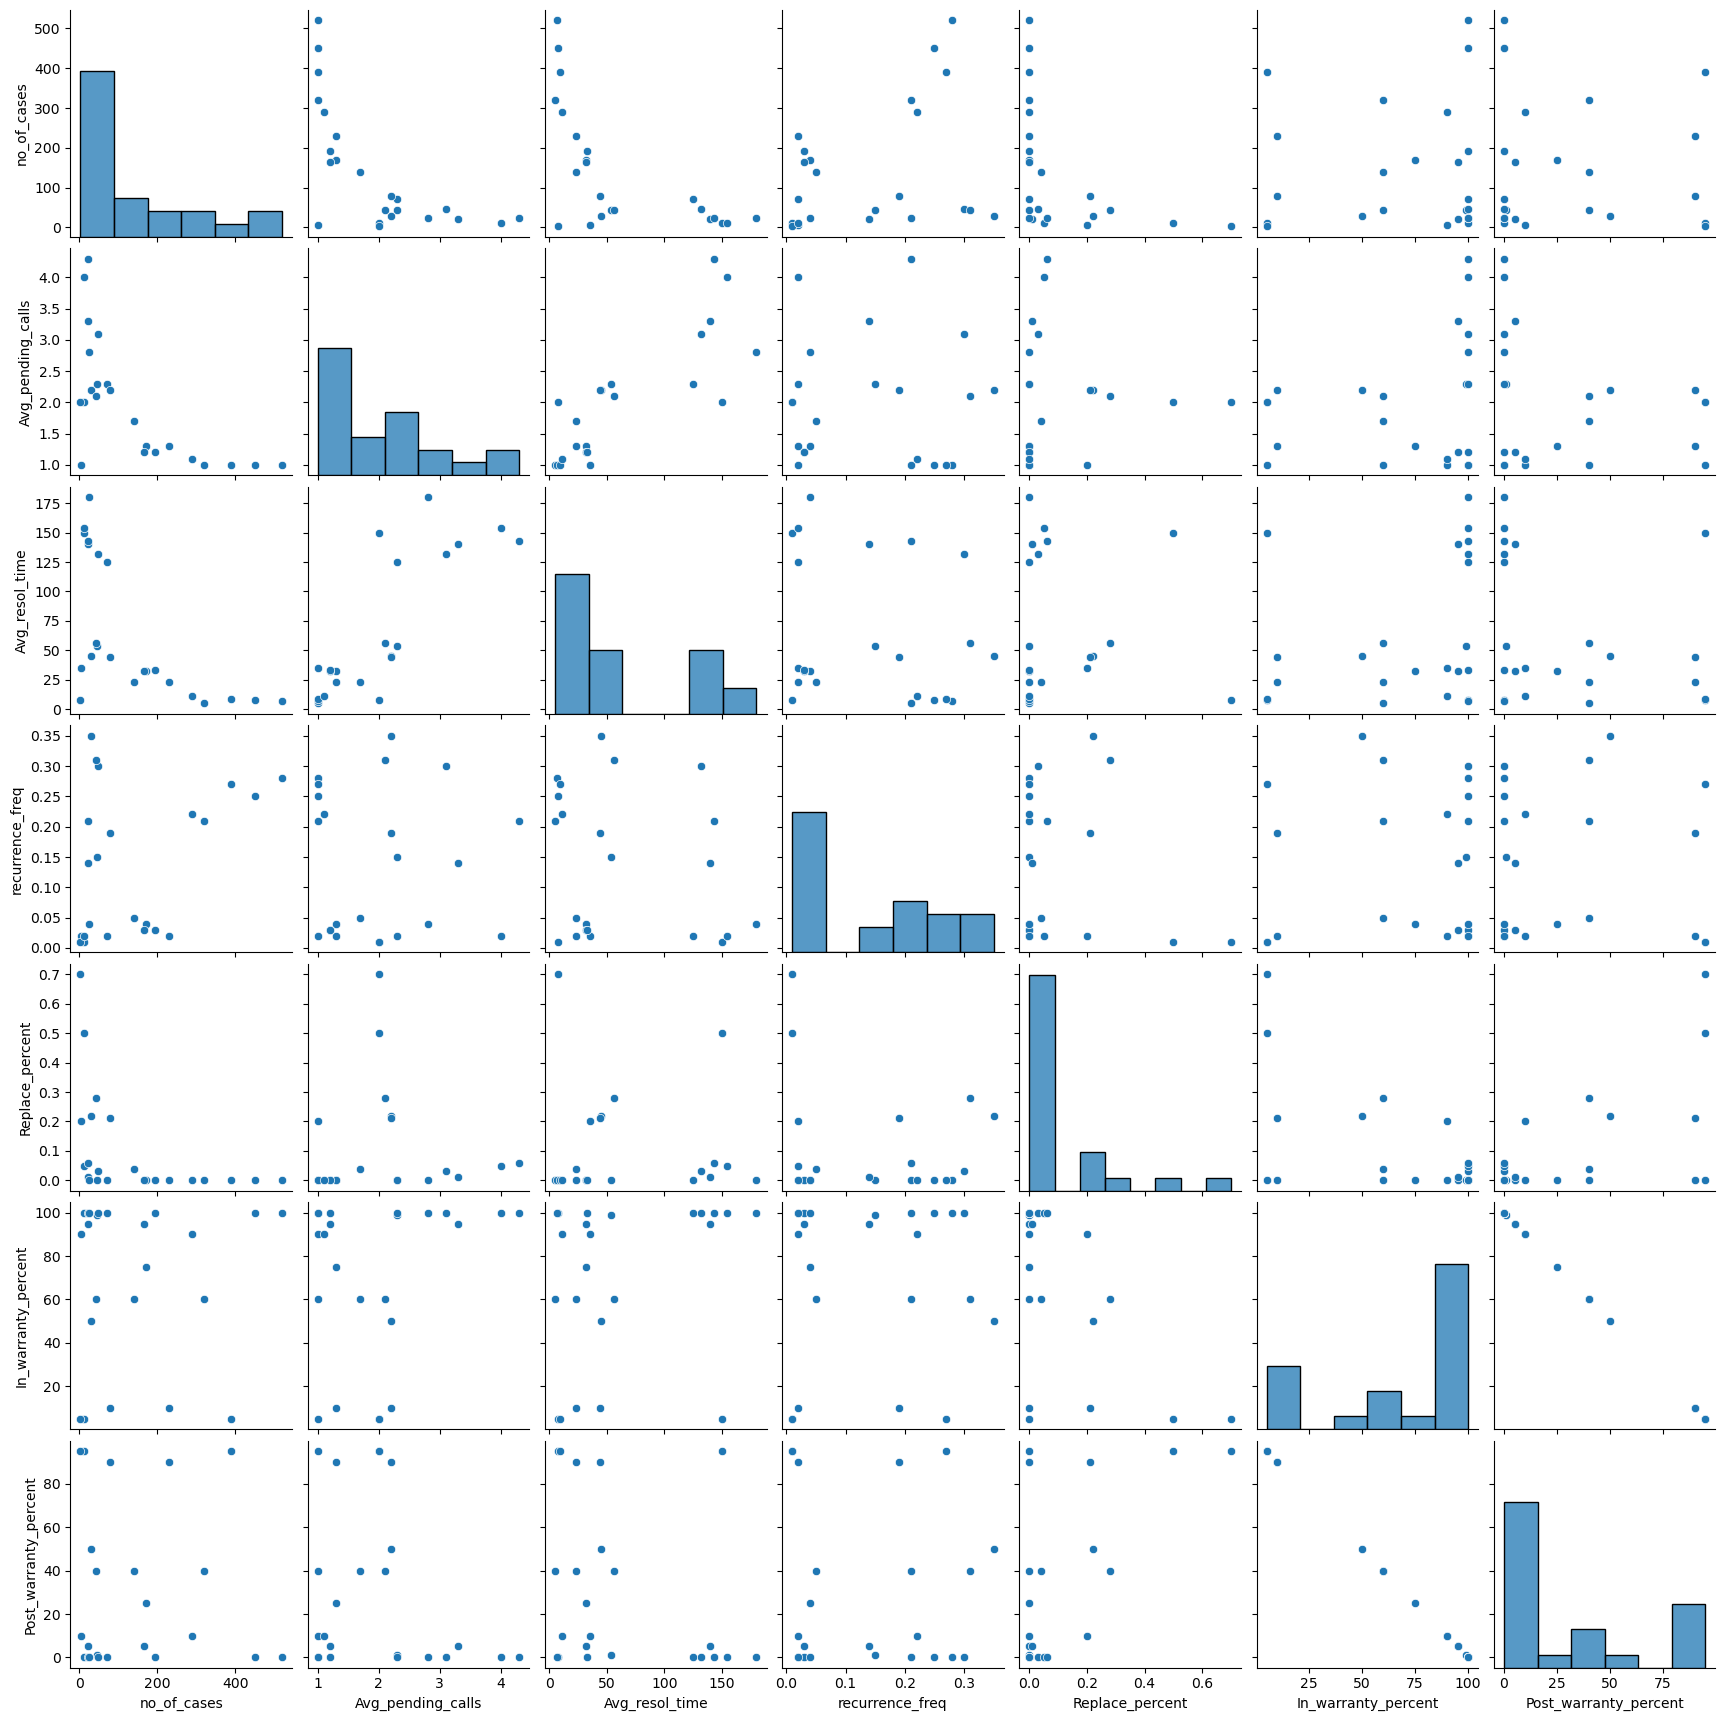

In [11]:
sns.pairplot(data)

In [12]:
attr=data.iloc[:,1:]

In [13]:
data_scaled=attr.apply(zscore)

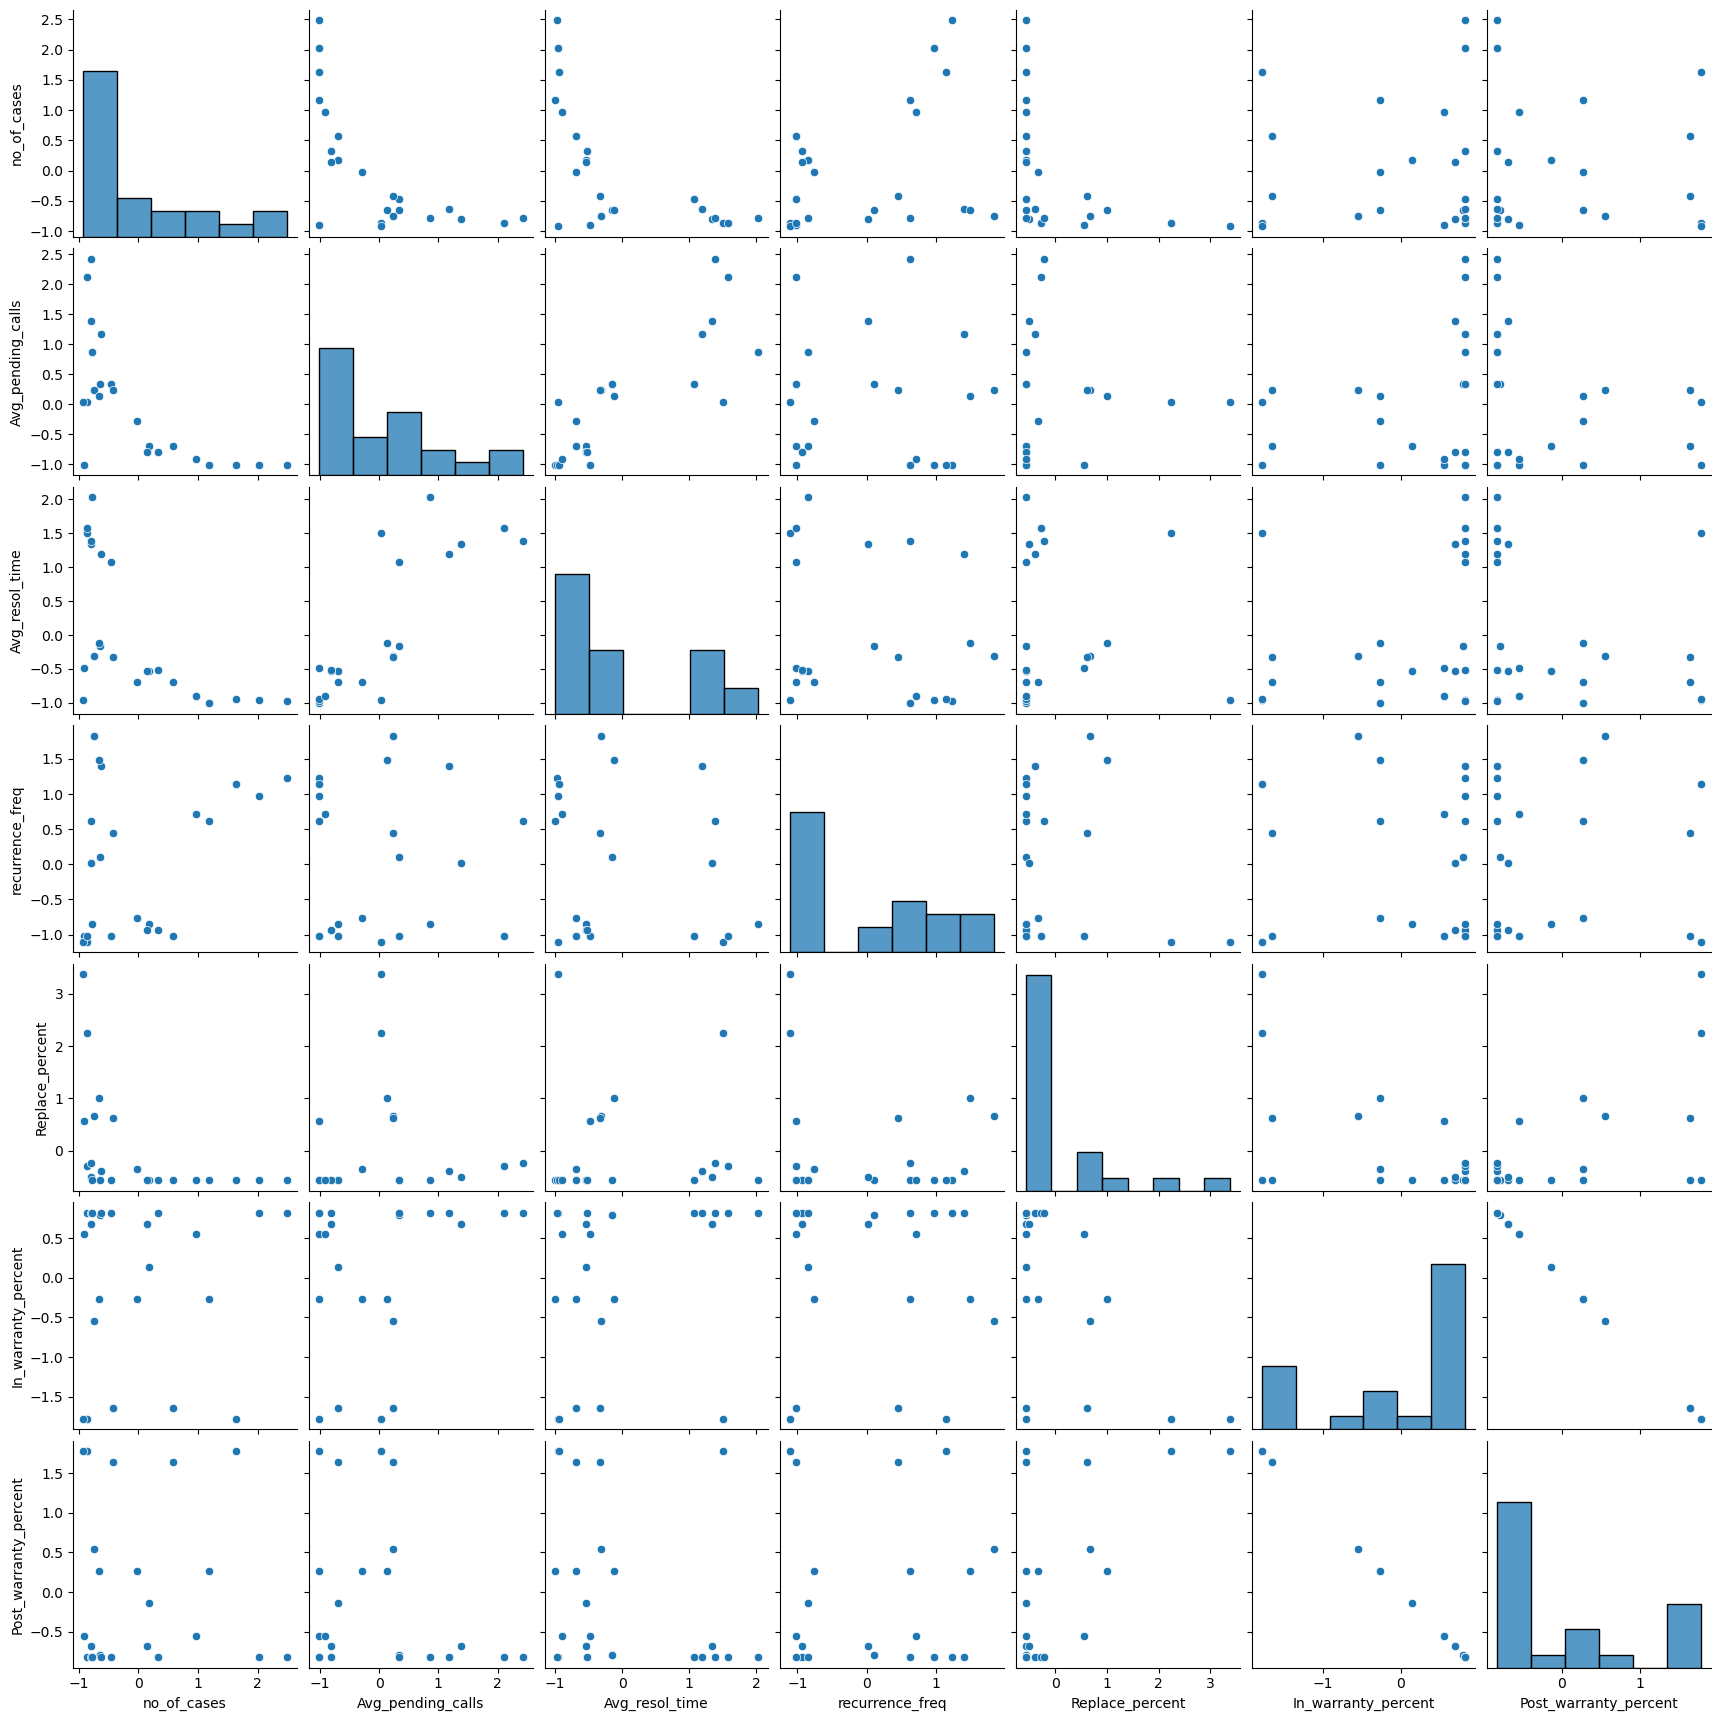

In [14]:
sns.pairplot(data_scaled)

In [15]:
from scipy.spatial.distance import cdist

In [16]:
clusters=range(1,10)

In [17]:
meandistortions=[]

In [18]:
for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(data_scaled)
    predict=model.predict(data_scaled)
    meandistortions.append(sum(np.min(cdist(data_scaled,model.cluster_centers_,'euclidean'),axis=1))/data_scaled.shape[0])

C:\Users\moham\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\moham\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\moham\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\moham\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environme

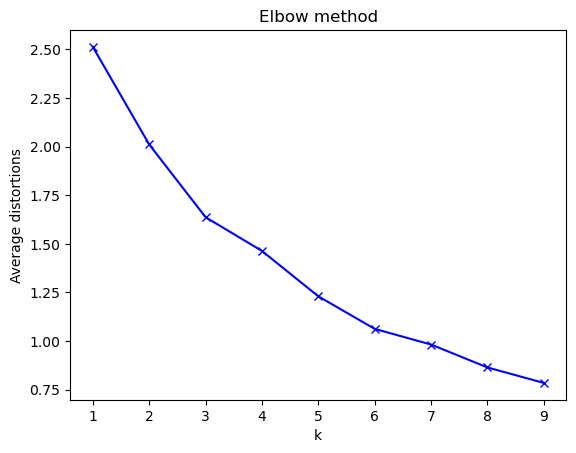

In [19]:
plt.plot(clusters,meandistortions,'bx-')
plt.xlabel('k')
plt.ylabel('Average distortions')
plt.title("Elbow method")
plt.show()

In [43]:
#k=5
model1=KMeans(3)
model1.fit(data_scaled)
prediction=model1.predict(data_scaled)

C:\Users\moham\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\moham\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [44]:
data_scaled['Group']=prediction

In [45]:
data_scaled.head()

,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent,Group
0,0.179429,-0.701207,-0.538351,-0.843188,-0.561463,0.138067,-0.138067,0
1,-0.862176,0.027143,1.510857,-1.101765,2.245854,-1.778204,1.778204,1
2,-0.908323,-1.013357,-0.486253,-1.015573,0.561463,0.548696,-0.548696,0
3,-0.921508,0.027143,-0.955140,-1.101765,3.368781,-1.778204,1.778204,1
4,-0.644625,0.339294,-0.156296,0.104930,-0.561463,0.795074,-0.795074,0


In [46]:
#Analyze the distribution of data
data_clusters=data_scaled.groupby(['Group'])
data_clusters.mean()

,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent
Group,,,,,,,
0,0.574316,-0.722017,-0.677281,-0.084694,-0.426712,0.463833,-0.463833
1,-0.201991,-0.151228,-0.262973,0.240375,0.970530,-1.348020,1.348020
2,-0.721537,1.379794,1.435604,-0.139282,-0.421098,0.799636,-0.799636


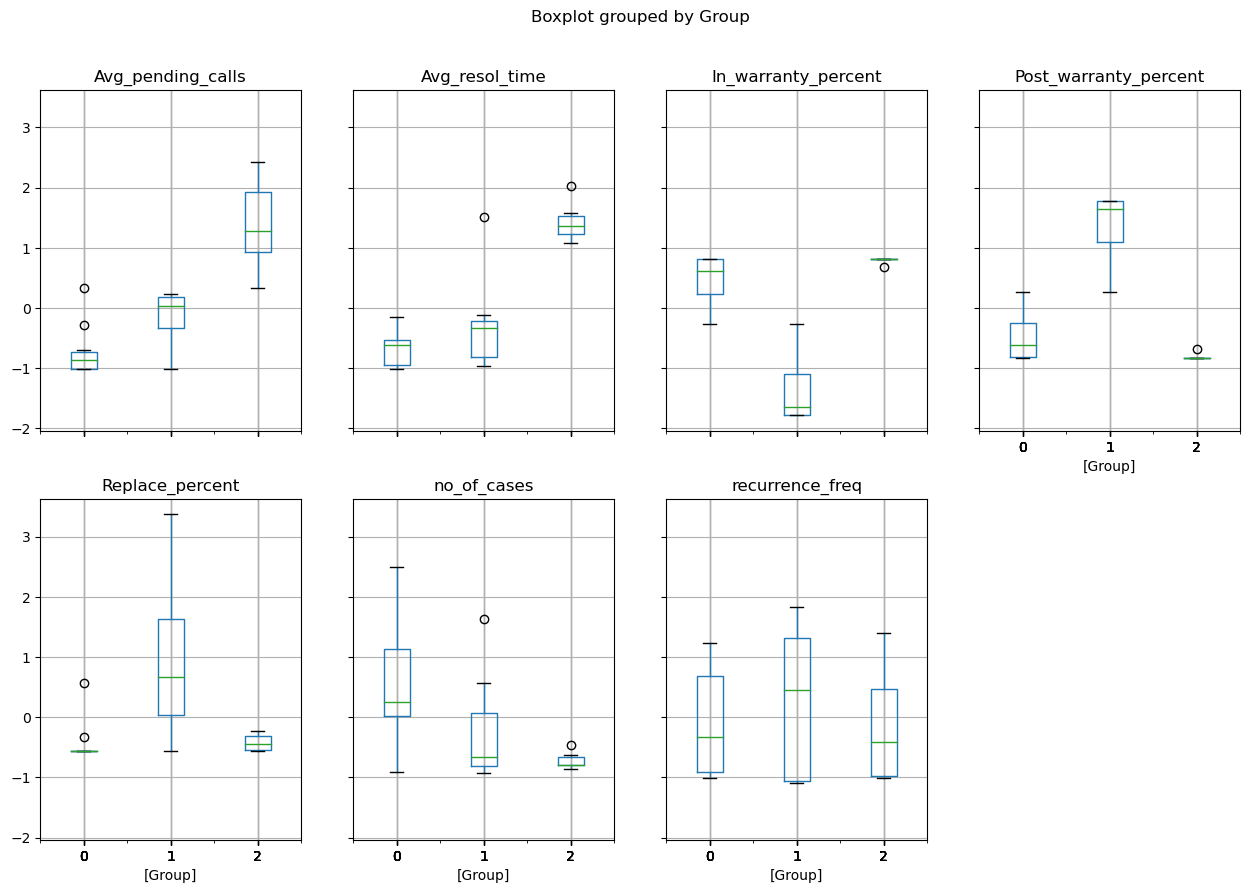

In [47]:
data_scaled.boxplot(by="Group",layout=(2,4),figsize=(15,10))
plt.show()